In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow/Keras for building and training the CNN
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# Fashion-MNIST: 70,000 grayscale images (28x28) of clothing across 10 classes
fashion_mnist = tf.keras.datasets.fashion_mnist

In [ ]:
# Load the train/test splits (60,000 train / 10,000 test images)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1] to help the network train faster and more stably
X_train, X_test = X_train / 255.0, X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Sanity-check the shapes before building the model
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


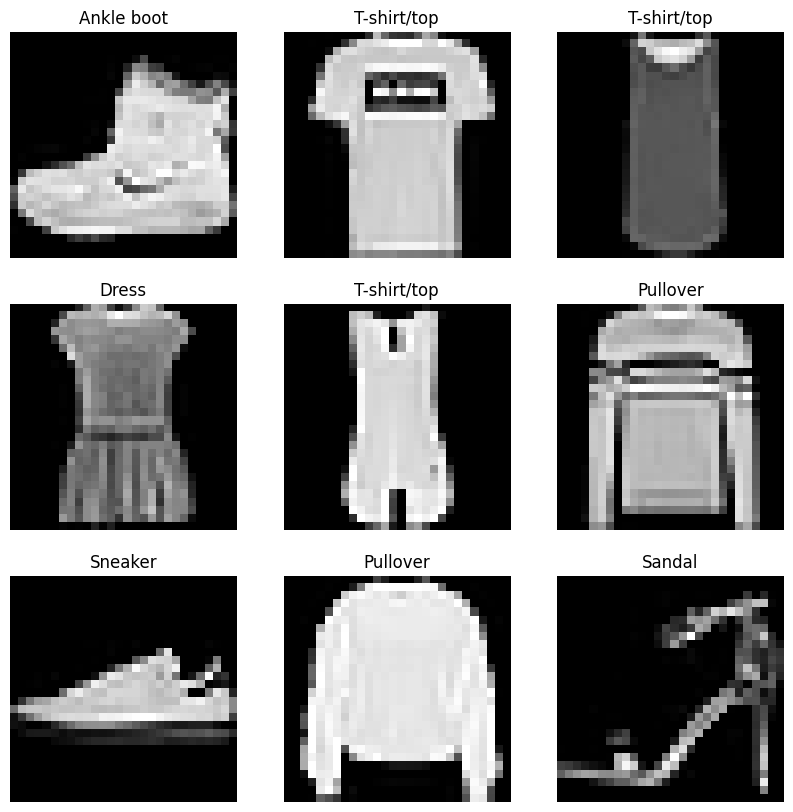

In [ ]:
# Labels are integers 0-9, so map them to readable clothing names for plotting
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [ ]:
# Build a small CNN:
# - Conv2D extracts local features (edges, textures) using 32 filters of size 3x3
# - MaxPooling2D downsamples the feature maps, reducing size and computation
# - Flatten converts the 2D feature maps into a 1D vector for the dense layers
# - Dense(64) learns combinations of the extracted features
# - Dense(10, softmax) outputs a probability distribution over the 10 clothing classes
model = models.Sequential([
    layers.Conv2D(32,(3,3), activation = 'relu',input_shape = (28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model:
# - Adam optimizer for efficient gradient descent
# - Sparse categorical crossentropy since labels are integers (not one-hot encoded)
# - Track accuracy during training
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
# Train for 5 epochs, holding out 10% of the training data for validation
history = model.fit(X_train, y_train, epochs = 5, validation_split = 0.1)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8547 - loss: 0.4152 - val_accuracy: 0.8773 - val_loss: 0.3417
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8992 - loss: 0.2836 - val_accuracy: 0.8973 - val_loss: 0.2833
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9117 - loss: 0.2429 - val_accuracy: 0.9100 - val_loss: 0.2583
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9243 - loss: 0.2112 - val_accuracy: 0.9117 - val_loss: 0.2529
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9319 - loss: 0.1865 - val_accuracy: 0.9120 - val_loss: 0.2496


In [ ]:
# Evaluate the trained model on the untouched test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9080 - loss: 0.2623
Test accuracy: 0.9080


In [ ]:
# Get predicted probabilities for each test image, then take the class with the highest probability
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# Build a confusion matrix comparing true labels vs predicted labels
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

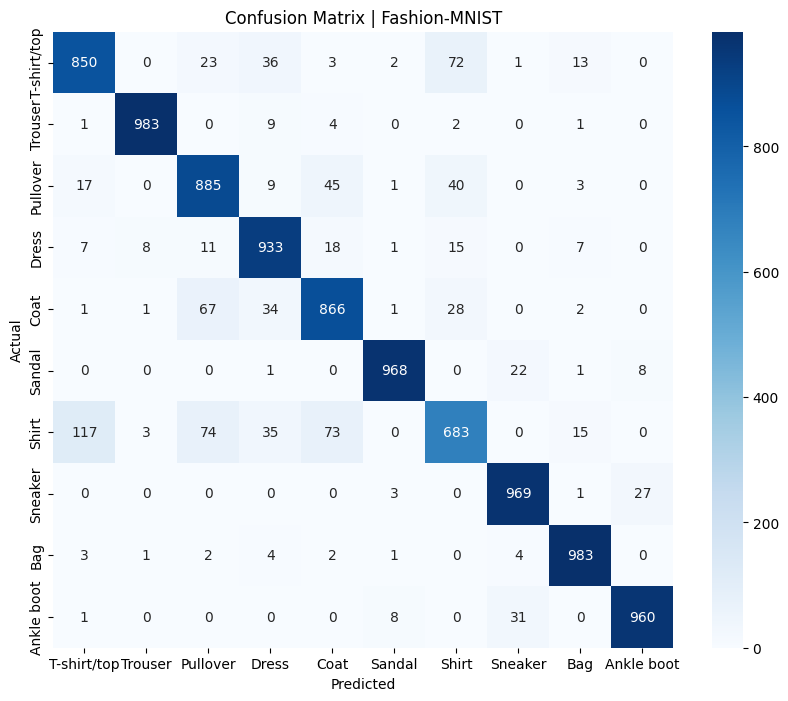

In [ ]:
# Visualize the confusion matrix as a heatmap to spot which classes get confused
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix | Fashion-MNIST')
plt.show()

In [ ]:
# Get per-class precision, recall, and F1-score for a more detailed breakdown than accuracy alone
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.85      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.83      0.89      0.86      1000
       Dress       0.88      0.93      0.91      1000
        Coat       0.86      0.87      0.86      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.81      0.68      0.74      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## Note

AI  was used to help add explanatory comments throughout this notebook, and assisted in writing a few lines of code.